In [2]:
library(tidyverse)
library(reshape2)

source("../theme_ggplot_cfrna.R")
source("../functions.R")
gene_key = read.delim("../gencode.biotype.name.key.tsv")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




In [ ]:
library(ggExtra)
library(ggforce)


# ## load data
mdf = read.delim("/sample_meta_passQC.tsv") %>% filter(ORIGIN == "DFCI")%>%
    mutate(timepoint_sym = factor(timepoint, levels = EVENTS_sym)) %>%
    unique()

metrics = read.delim("/metrics_passQC.tsv")

### factor timepoint
mdf = mdf %>% 
    mutate(timepoint = factor(timepoint, levels = EVENTS)) 
    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_sym)) %>% 
   

mdf$timepoint <- droplevels(mdf$timepoint)
mdf$timepoint_sym <- droplevels(mdf$timepoint_sym)

mdf = mdf %>% mutate(sample_group = factor(sample_group, levels = c("HD", "REF", "COMP"))) 


# Combine with metrics and melt for plotting
mdf_met = merge(mdf, metrics, by="sample_id", all.x=FALSE)


mdf_met = mdf_met %>% 
    select(sample_id, timepoint_sym, HD, sample_group, neutrophil_CBC, neutrophil_decon, monocyte_CBC, monocyte_decon, lymphocyte_CBC, lymphocyte_decon) %>%
    reshape2::melt(.,id.vars = c("sample_id", "timepoint_sym","HD","sample_group")) %>% 
    mutate(measurement = gsub(".*_","",variable)) %>%
    mutate(measurement2 = ifelse(measurement == "decon","CTO Fraction","CBC")) %>%
    mutate(celltype = gsub("_.*","",variable))



In [8]:
library(ggpubr)


Attaching package: ‘ggpubr’


The following object is masked from ‘package:cowplot’:

    get_legend




In [73]:
mdf_met <- mdf_met %>% dplyr::filter(timepoint_sym %in% c("Healthy Donor", "1 Month","Day of Infusion","Engraftment","2 Month","3 Month","6 Month", "Pre-Conditioning"))

Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in stat_compare_means(aes(group = sample_group, method = "wilcox.test", :
“Ignoring unknown aesthetics: method”
Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


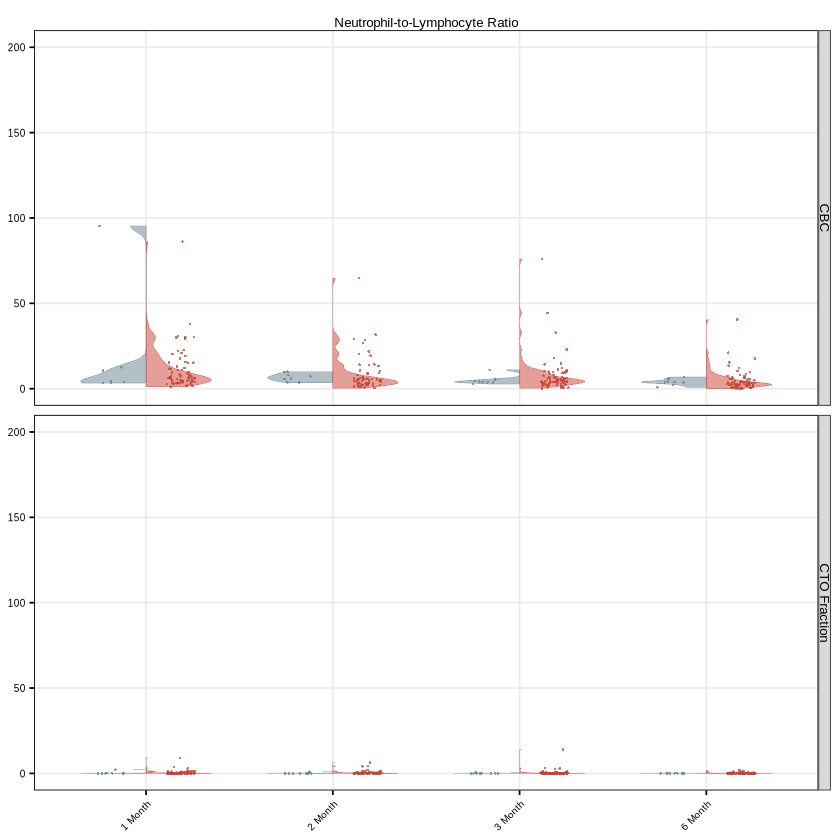

Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


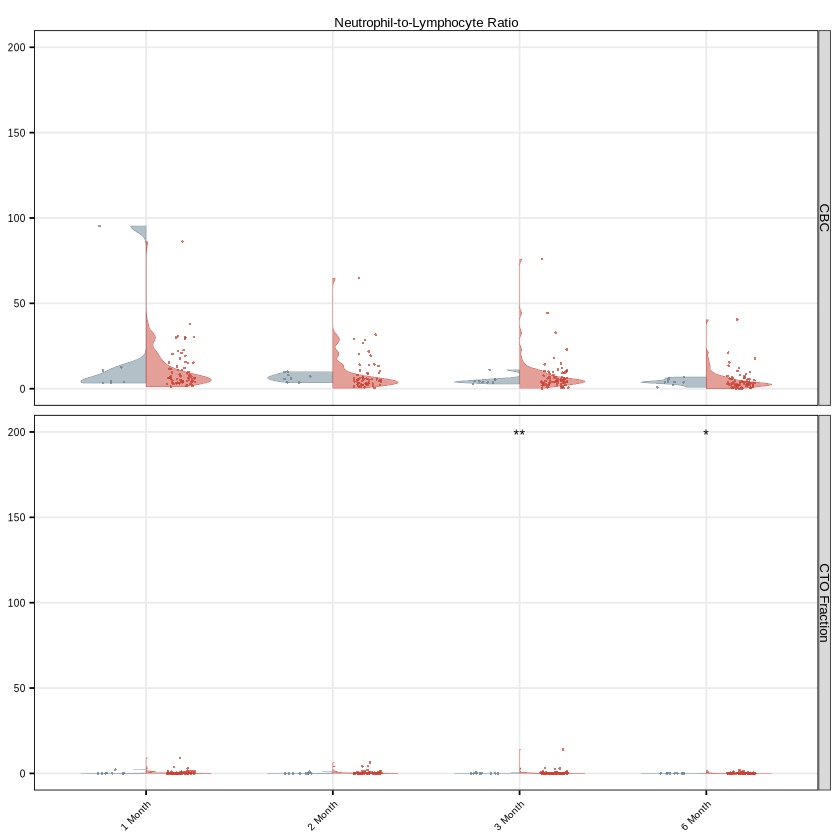

In [ ]:

library(ggpubr)
nlr_df <- mdf_met %>%
    filter(!is.na(value))%>%
    filter(celltype %in% c("neutrophil", "lymphocyte")) %>%
    select(sample_id, timepoint_sym, sample_group, HD, measurement2, celltype, value) %>%
    pivot_wider(names_from = celltype, values_from = value) %>%
    filter(!is.na(neutrophil), !is.na(lymphocyte), lymphocyte > 0) %>%
    mutate(
        value    = neutrophil / lymphocyte,
        celltype = "NLR"
    ) %>%
    select(-neutrophil, -lymphocyte)


CT <- "NLR"

REMOVE_IDS <- nlr_df %>%
    filter(is.na(value)) %>%
    pull(sample_id)

viol_plt <- nlr_df %>%
    filter(!sample_id %in% REMOVE_IDS) %>%
    mutate(HD = factor(HD, levels = c(1, 0))) %>%
    mutate(sample_group = factor(sample_group, levels = c("REF","COMP"))) %>%
    ggplot(aes(x = timepoint_sym, y = value, color = sample_group, fill = sample_group)) +
        geom_split_violin(scale ="width",width = 0.7, alpha = 0.5, size = 0.1)+
        geom_point(size = 0.75, alpha = 0.75, stroke = NA,
            position = position_jitterdodge(jitter.height = 0, jitter.width = .3, seed = 42)) +
        theme_cfrna_print() +
        facet_grid(measurement2 ~ HD, scales = "free", space = "free_x") +
        theme(
            axis.text.x      = element_text(size = 6, angle = 45, hjust = 1),
            plot.title       = element_text(size = 8, hjust = 0.5, vjust = -2),
            axis.title       = element_blank(),
            strip.text.x = element_blank(),
            panel.grid.minor = element_blank(),
            panel.background = element_rect(fill = "transparent", color = "transparent"),
            plot.background  = element_rect(fill = "transparent", color = "transparent")
        ) +
        labs(title = "Neutrophil-to-Lymphocyte Ratio") +
        ylim(0, 200) +
        scale_color_manual(values = COLORs) +
        scale_fill_manual(values = COLORs)

viol_plt
viol_plt + stat_compare_means(
    aes(group = sample_group, method = "wilcox.test", label = after_stat(p.signif)),
    symnum.args = list(cutpoints = c(0, 0.0001, 0.001, 0.01, 0.1, Inf),
                       symbols   = c("****", "***", "**", "*", "ns")),
    size    = 3,
    vjust   = .75,
    hide.ns = TRUE
)

WIDTH = 2.3
HEIGHT = 2.75
ggsave("/VIOLIN_NLR.pdf", width = WIDTH, height = HEIGHT, units = "in")


## CTO x Cell counts - scatter

In [ ]:
library(ggExtra)

## load data
mdf = read.delim("/sample_meta_passQC.tsv") %>% 
    filter(ORIGIN == "DFCI") %>% 
    filter(timepoint %in% c("1M","2M","3M","6M"))

metrics = read.delim("/metrics_passQC.tsv") #%>% select(!SCALE_qubit)

metrics %>% head

mdf_metrics = merge(mdf, metrics, by="sample_id")

WIDTH = 2.23
HEIGHT = 2.23


#save for SBIR
# merge(mdf, metrics, by="sample_id") %>% write.csv("/workdir/cjl332/SBIR/prepr_202504/CTO_Ccounts.csv",row.names=FALSE)



,sample_id,avgCorrelation_trajectory,neutrophil_activity,lymphocyte_activity,leukocyte_activity,platelet_activity,rbc_activity,monocyte_activity,basophil_activity,neutrophil_CBC,⋯,leukocyte_decon,platelet_decon,rbc_decon,monocyte_decon,basophil_decon,G2M_Z,S_Z,repHistone_CPM,nonrepHistone_CPM,simpson
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,gvhd_hct_cfrna_1_bp51x51,0.6800281,NA,NA,NA,NA,NA,NA,NA,NA,⋯,0.47972935,0.2316019,4.586281e-06,1.046424e-01,5.119471e-03,-15.374315,-10.646876,3719.898,1130.7854,0.8661505
2,gvhd_hct_cfrna_100_bp61x61,0.7013759,8.782792e-12,NA,2.219994e-11,4.599910e-12,5.451422e-11,4.572892e-13,NA,4.05,⋯,0.12768230,0.4332355,2.738314e-01,1.607912e-04,9.561984e-05,43.977934,11.941185,14140.208,1779.1504,0.7271987
3,gvhd_hct_cfrna_101_bp61x61,0.8456596,2.571963e-15,2.722830e-10,4.205989e-11,2.219168e-12,9.685403e-12,6.687443e-13,7.893676e-12,3.47,⋯,0.31652864,0.4943412,5.175126e-02,4.428816e-04,2.376206e-04,-21.844124,-13.806422,8698.650,1164.8105,0.7044119
4,gvhd_hct_cfrna_102_bp61x61,0.8347522,1.306607e-15,1.080224e-10,4.552077e-12,1.222693e-12,1.519625e-12,2.922352e-14,NA,3.21,⋯,0.05982032,0.7874591,2.206305e-02,1.958256e-05,5.035800e-05,-20.694226,-22.440580,5420.162,959.6953,0.3725581
5,gvhd_hct_cfrna_103_bp61x61,0.8040592,8.377165e-12,6.309881e-11,2.013788e-11,2.556231e-12,9.110483e-12,1.558795e-12,NA,3.08,⋯,0.22575686,0.4829280,4.514011e-02,1.583581e-03,4.310301e-05,-8.168314,-6.979535,6950.196,1169.6046,0.7270608
6,gvhd_hct_cfrna_104_bp61x61,0.8145737,1.455608e-14,3.794148e-12,3.141391e-12,1.051612e-12,1.079548e-11,NA,1.569389e-13,0.12,⋯,0.01959784,0.6931229,1.095841e-01,1.132550e-05,2.212604e-05,9.947486,-20.719633,9482.132,1202.6346,0.4942068


In [59]:


## NLR (Neutrophil-to-Lymphocyte Ratio) - built the same way as the Marg_NLR plot (cell 34):
## NLR_decon = neutrophil_decon / lymphocyte_decon, NLR_CBC = neutrophil_CBC / lymphocyte_CBC
VAR1 = "NLR_decon"
VAR2 = "NLR_CBC"

t = mdf_metrics %>%
    filter(neutrophil_CBC != 0, lymphocyte_CBC != 0,
           neutrophil_decon != 0, lymphocyte_decon != 0) %>%
    mutate(
        NLR_decon = neutrophil_decon / lymphocyte_decon,
        NLR_CBC   = neutrophil_CBC   / lymphocyte_CBC
    ) %>%
    filter(!is.na(.data[[VAR1]]) & !is.na(.data[[VAR2]])) %>%
    filter(.data[[VAR2]] > 0)
t1 = t %>% pull(VAR1) %>% log10()
t2 = t %>% pull(VAR2) %>% log10()
wilcox.test(t1,t2)
cor.test(t1,t2)



	Wilcoxon rank sum test with continuity correction

data:  t1 and t2
W = 2417, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Pearson's product-moment correlation

data:  t1 and t2
t = 3.5809, df = 293, p-value = 0.0004006
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.09273905 0.31167787
sample estimates:
      cor 
0.2047683 


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


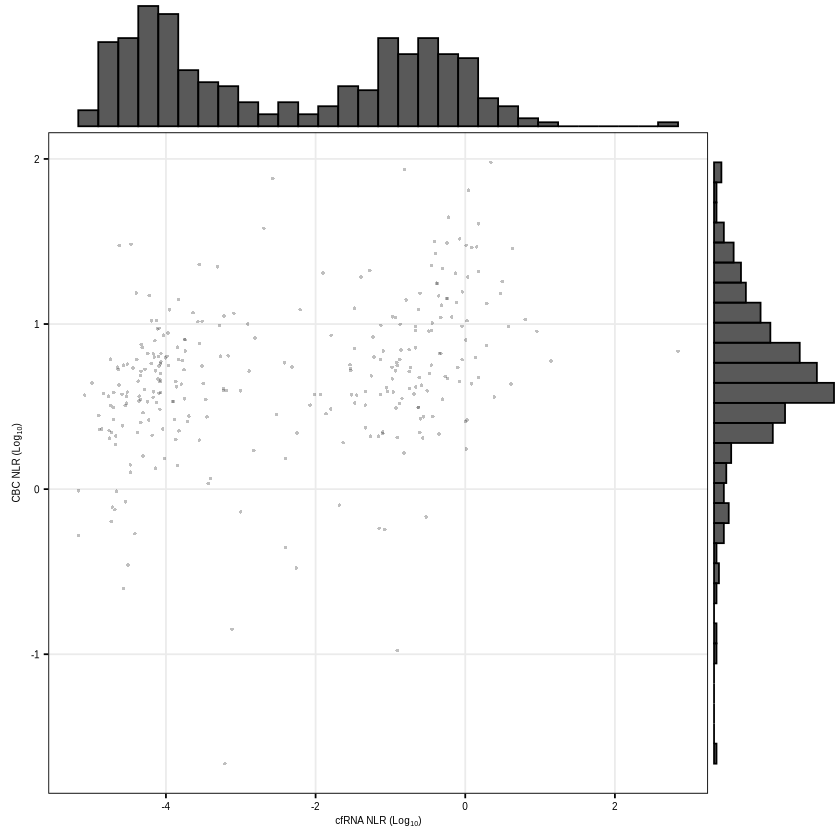

In [69]:
## NLR CORRELATION

plt_nlr <- merge(mdf, metrics, by="sample_id") %>%
    filter(neutrophil_CBC != 0, lymphocyte_CBC != 0,
           neutrophil_decon != 0, lymphocyte_decon != 0) %>%
    mutate(
        NLR_CBC   = neutrophil_CBC   / lymphocyte_CBC,
        NLR_decon = neutrophil_decon / lymphocyte_decon
    ) %>%
    ggplot(aes(x = log10(NLR_decon), y = log10(NLR_CBC))) +
    geom_point(size = 1, alpha = 0.25, stroke = NA) +
    theme_cfrna_print() +
    scale_fill_manual(values  = COLORs) +
    scale_color_manual(values = COLORs) +
    theme(
        panel.grid.minor = element_blank(),
        panel.background = element_rect(fill = "white",       color = "white"),
        plot.background  = element_rect(fill = "transparent", color = "transparent")
    ) +
    labs(
        x = bquote("cfRNA NLR ("*Log[10]*")"),
        y = bquote("CBC NLR ("*Log[10]*")")
    )

plt_nlr_marg <- ggMarginal(plt_nlr,
                            type    = "histogram",
                            xparams = list(bins = 30))

ggsave("/workdir/gfa32/hsct_new/PAPER2_cfrna/revisions/CommsMed/figures/Marg_NLR.pdf", plt_nlr_marg, width = WIDTH, height = HEIGHT, units = "in", bg = "transparent")
plt_nlr_marg
